# Auckland Property Price Prediction — Data Prep Pipeline

Pipeline stages: **1. Import data → 2. Preprocessing → 3. Exploratory analysis → 4. Prepare train/test sets for modeling.**

Target variable: `sale_price_gross`. Train/test split: time-based (train on
earlier sales, test on the most recent)

## 1. Import data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)

df = pd.read_parquet("./cache/dvrs_processed.parquet")
print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()


Loaded 90,738 rows, 53 columns


,valuation_roll_number,valuation_number_assessment,valuation_number_suffix,sale_date,district_code,sale_type,sales_group,sale_tenure,price_value_relationship,sale_price_gross,sale_price_net,sale_price_chattels,sale_price_other,capital_value,land_value,current_effective_valuation_date,situation_number,additional_situation_number,situation_name,certificate_of_title,land_area,zoning,actual_property_use,units_of_use,off_street_parking,building_age_indicator,building_condition_indicator,building_construction_indicator,building_site_coverage,building_total_floor_area,property_category,legal_description,mass_contour,mass_view,mass_scope_of_view,mass_total_floor_area,mass_deck,mass_workshop_laundry,mass_other_improvements,mass_garage_under_main_roof,mass_garage_freestanding,geocode_confidence,longitude,latitude,matched_suburb,matched_postcode,in_flood_plain,in_flood_sensitive_area,unitary_plan_zone,situation_name_expanded,dist_to_flood_plain_m,dist_to_flood_sensitive_area_m,street_in_linz
0,1,2501710000,NaN,25022026,14,S,701,1,1,1514000,1499000,15000,0,1400000,1025000,45413,166,NaN,Point Chevalier RD,335510,0,9C,91,1,1,192,GG,WI,80,87,RD192A,"Carport 1 DP 384040, Flat 1 DP 384040,",LV,N,N,87,Y,N,N,0,1,0.936853,174.7063887333,-36.86568815,Point Chevalier,1022,False,False,60.0,Point Chevalier Road,241.910185,4866.407069,True
1,1,2600010100,NaN,1042025,14,S,701,1,1,1515112,1507112,8000,0,1675000,1500000,44348,7,NaN,Montrose ST,NA118D/908,0.0403,9D,91,1,0,193,AA,WT,120,117,RD193B,Lot 2 DP 189123 403m2,LV,N,N,117,Y,N,N,0,0,0.639003,174.7087791667,-36.8694169333,Point Chevalier,1022,False,False,8.0,Montrose Street,194.452135,4614.989420,True
2,1,4300000201,NaN,14022025,14,S,701,1,1,1622800,1609800,13000,0,1650000,1360000,44348,5,NaN,St Michaels AV,NA57C/301,0,9C,91,1,1,198,AA,WT,60,124,RD198B,"Flat 3 DP 103999, Lot 4 DP 7475 652m2",LV,N,N,124,Y,N,N,1,0,0.728003,174.7028569,-36.8613287333,Point Chevalier,1022,False,False,60.0,St Michaels Avenue,196.291955,4670.897421,True
3,1,4300110000,NaN,17012025,14,S,701,1,1,2105000,2092000,13000,0,2600000,2325000,44348,35,NaN,St Michaels AV,NA405/218,0.0656,9B,91,1,1,193,AA,WT,120,123,RD193B,Lot 2 DP 15494 656m2,EF,N,N,123,Y,N,N,0,0,0.742648,174.7008459833,-36.86233865,Point Chevalier,1022,False,False,18.0,St Michaels Avenue,18.820703,4814.776819,True
4,1,4300270001,NaN,11112025,14,S,701,1,2,1875000,1862000,13000,0,2300000,2025000,45413,66,NaN,St Michaels AV,115395,0.0396,9B,91,1,1,192,AA,WI,137,124,RD192B,Lot 1 DP 328302 396m2,EF,W,M,109,Y,N,N,1,0,0.751518,174.6988467667,-36.8636163333,Point Chevalier,1022,False,False,18.0,St Michaels Avenue,6.764028,4804.594688,True


In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 90738 entries, 0 to 92009
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   valuation_roll_number             90738 non-null  str    
 1   valuation_number_assessment       90738 non-null  str    
 2   valuation_number_suffix           14016 non-null  str    
 3   sale_date                         90738 non-null  str    
 4   district_code                     90738 non-null  str    
 5   sale_type                         90737 non-null  str    
 6   sales_group                       90738 non-null  str    
 7   sale_tenure                       90738 non-null  str    
 8   price_value_relationship          90738 non-null  str    
 9   sale_price_gross                  90738 non-null  str    
 10  sale_price_net                    90738 non-null  str    
 11  sale_price_chattels               90738 non-null  str    
 12  sale_price_other    

## 2. Data preprocessing

### 2.1 Filter to reliable, genuine owner-occupier market sales

- `zoning` (first digit in 9, 1, 2): keep residential, rural and lifestyle
  zones; drops commercial / industrial / community properties (e.g. a
  supermarket building), which aren't houses an individual buys.
- `units_of_use == "1"`: a single unit rather than a block of several (e.g.
  a bunch of apartments). Much other council data is only supplied when
  units = 1 and is NA otherwise.
- `sale_tenure == "1"`: freehold sales, where the buyer owns the property
  and land -- fundamentally different from leasing the land.
- `sale_type == "S"`: any other record means more than one property was
  sold at once (e.g. a developer buying several houses), so the price is
  the combined price while the features describe only one property.
- `price_value_relationship == "1"`: arm's-length sale at market price.
  Other codes are not driven by pure market forces (e.g. parents selling
  to children at a discount), so the price doesn't reflect market value.
- `street_in_linz`: dropped rows whose street name doesn't exist anywhere
  in LINZ's address register, since their geocoded coordinates are a
  forced wrong guess.


In [3]:
before = len(df)
df = df[df["zoning"].astype(str).str[0].isin(["9", "1", "2"])]
print(f"Residential / rural / lifestyle zoning only (first digit 9, 1, 2): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["units_of_use"].astype(str) == "1"]
print(f"Single unit of use only (units_of_use == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["sale_tenure"].astype(str) == "1"]
print(f"Freehold sales only (sale_tenure == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["sale_type"] == "S"]
print(f"Single-property sales only (sale_type == 'S'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["price_value_relationship"] == "1"]
print(f"Arm's-length market sales only (price_value_relationship == '1'): {len(df):,} / {before:,} rows kept")

before = len(df)
df = df[df["street_in_linz"]]
print(f"Geocoded street confirmed to exist in LINZ: {len(df):,} / {before:,} rows kept")

print()
print(f"Final filtered shape: {df.shape}")


Residential / rural / lifestyle zoning only (first digit 9, 1, 2): 80,070 / 90,738 rows kept
Single unit of use only (units_of_use == '1'): 77,370 / 80,070 rows kept
Freehold sales only (sale_tenure == '1'): 76,395 / 77,370 rows kept
Single-property sales only (sale_type == 'S'): 74,112 / 76,395 rows kept
Arm's-length market sales only (price_value_relationship == '1'): 61,244 / 74,112 rows kept
Geocoded street confirmed to exist in LINZ: 57,044 / 61,244 rows kept

Final filtered shape: (57044, 53)


### 2.2 Parse dates

In [4]:
def parse_sale_date(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s)
    year = int(s[-4:])
    month = int(s[-6:-4])
    day = int(s[:-6])
    return pd.Timestamp(year=year, month=month, day=day)


df["sale_date_parsed"] = df["sale_date"].apply(parse_sale_date)

df["current_effective_valuation_date_parsed"] = pd.to_datetime(
    df["current_effective_valuation_date"].astype(int), unit="D", origin="1899-12-30"
)

print(df[[
    "sale_date", "sale_date_parsed",
    "current_effective_valuation_date", "current_effective_valuation_date_parsed",
]].head())
print()
print("sale_date_parsed range:", df["sale_date_parsed"].min().date(), "to", df["sale_date_parsed"].max().date())


  sale_date sale_date_parsed current_effective_valuation_date  \
0  25022026       2026-02-25                            45413   
1   1042025       2025-04-01                            44348   
2  14022025       2025-02-14                            44348   
3  17012025       2025-01-17                            44348   
5  20032025       2025-03-20                            44348   

  current_effective_valuation_date_parsed  
0                              2024-05-01  
1                              2021-06-01  
2                              2021-06-01  
3                              2021-06-01  
5                              2021-06-01  

sale_date_parsed range: 2024-01-01 to 2026-08-18


### 2.3 Convert numeric columns

Select features that should be numerical values.

In [5]:
numeric_cols = [
    "sale_price_gross", "sale_price_net", "sale_price_chattels", "sale_price_other",
    "capital_value", "land_value", "land_area", "building_total_floor_area",
    "mass_total_floor_area", "building_site_coverage", "off_street_parking",
    "units_of_use", "mass_garage_under_main_roof", "mass_garage_freestanding",
    "longitude", "latitude",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols].describe()


,sale_price_gross,sale_price_net,sale_price_chattels,sale_price_other,capital_value,land_value,land_area,building_total_floor_area,mass_total_floor_area,building_site_coverage,off_street_parking,units_of_use,mass_garage_under_main_roof,mass_garage_freestanding,longitude,latitude
count,5.704400e+04,5.704400e+04,5.704400e+04,57044.000000,5.704400e+04,5.704400e+04,57044.000000,57044.000000,57044.000000,57044.000000,57044.000000,57044.0,57044.000000,57044.000000,57044.000000,57044.000000
mean,1.214143e+06,1.015926e+06,1.981760e+05,13.207244,1.265744e+06,8.241030e+05,0.203703,164.702510,129.948794,118.057289,1.388297,1.0,0.878269,0.390295,174.777614,-36.875666
std,8.892736e+05,2.190803e+07,2.188810e+07,2721.356646,8.535227e+05,6.831466e+05,3.622170,2262.380916,62.783677,2513.751695,2.193309,0.0,0.919366,0.712380,0.121827,0.152131
min,8.500000e+02,-2.649956e+09,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,174.173049,-37.296482
25%,8.000000e+05,7.870000e+05,8.000000e+03,0.000000,8.400000e+05,4.700000e+05,0.007100,97.000000,91.000000,70.000000,1.000000,1.0,0.000000,0.000000,174.694809,-36.956893
50%,1.000000e+06,9.880000e+05,1.500000e+04,0.000000,1.075000e+06,6.600000e+05,0.035700,134.000000,118.000000,100.000000,1.000000,1.0,1.000000,0.000000,174.762251,-36.888147
75%,1.371000e+06,1.355000e+06,2.000000e+04,0.000000,1.436250e+06,9.700000e+05,0.067300,188.000000,160.000000,138.000000,2.000000,1.0,2.000000,1.000000,174.878669,-36.803153
max,5.995000e+07,5.995000e+07,2.651081e+09,640000.000000,6.250000e+07,6.250000e+07,482.000000,360000.000000,926.000000,600060.000000,301.000000,1.0,45.000000,10.000000,175.540537,-36.053132


### 2.4 Feature engineering

- `sale_year`/`sale_month`/`sale_quarter`: captures market trend over the
  2024-2026 sales window.
- `property_type`: the first character of `property_category` (e.g. the
  `"R"` in `"RD197B"`) — the broad property type (residential/commercial/
  industrial/etc.). `property_category` itself has 359 distinct values
  (type + quality grade + age + improvement codes all packed together), far
  too granular to use raw without exploding dimensionality.
- `land_value_ratio`: `land_value / capital_value` — the share of the
  council's assessed value that's land vs. improvements.
- `has_flood_risk`: `in_flood_plain OR in_flood_sensitive_area`, a single
  combined exposure flag alongside the two separate ones.

In [6]:
df["sale_year"] = df["sale_date_parsed"].dt.year
df["sale_month"] = df["sale_date_parsed"].dt.month
df["sale_quarter"] = df["sale_date_parsed"].dt.quarter

df["property_type"] = df["property_category"].str[0]

df["land_value_ratio"] = df["land_value"] / df["capital_value"].replace(0, np.nan)

df["has_flood_risk"] = df["in_flood_plain"] | df["in_flood_sensitive_area"]

df[["sale_year", "sale_month", "sale_quarter", "property_type", "land_value_ratio", "has_flood_risk"]].describe(include="all")


,sale_year,sale_month,sale_quarter,property_type,land_value_ratio,has_flood_risk
count,57044.000000,57044.000000,57044.000000,57044,57042.000000,57044
unique,NaN,NaN,NaN,10,NaN,2
top,NaN,NaN,NaN,R,NaN,False
freq,NaN,NaN,NaN,55231,NaN,52576
mean,2024.784237,6.164294,2.380338,NaN,0.639415,NaN
std,0.728800,3.334782,1.115604,NaN,0.180291,NaN
min,2024.000000,1.000000,1.000000,NaN,0.055046,NaN
25%,2024.000000,3.000000,1.000000,NaN,0.493976,NaN
50%,2025.000000,6.000000,2.000000,NaN,0.613953,NaN
75%,2025.000000,9.000000,3.000000,NaN,0.784582,NaN


### 2.5 Handle missing values

Semantic, per-column handling rather than a blanket median/mode fill —
several "missing" codes carry real meaning (e.g. `unitary_plan_zone` being
null means the property is outside any mapped zone, not a random gap).

In [7]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(missing)

valuation_number_suffix            82.464413
additional_situation_number        68.024683
building_condition_indicator        2.825889
building_construction_indicator     2.796087
building_age_indicator              2.704930
mass_other_improvements             1.847697
mass_workshop_laundry               1.619802
mass_deck                           1.135965
unitary_plan_zone                   0.669659
mass_scope_of_view                  0.366384
mass_view                           0.364631
mass_contour                        0.334829
matched_suburb                      0.010518
land_value_ratio                    0.003506
matched_postcode                    0.001753
dtype: float64


In [8]:
categorical_with_unknown = [
    "building_age_indicator", "building_condition_indicator", "building_construction_indicator",
    "mass_contour", "mass_view", "mass_scope_of_view", "mass_deck", "mass_workshop_laundry",
    "mass_other_improvements", "zoning", "property_type", "matched_suburb",
]
for col in categorical_with_unknown:
    df[col] = df[col].fillna("Unknown")

# unitary_plan_zone: NaN means the property falls outside any mapped Unitary
# Plan base zone polygon -- a real, distinct category, not a random gap.
df["unitary_plan_zone"] = df["unitary_plan_zone"].fillna(-1).astype(int).astype(str)

# land_value_ratio: only undefined when capital_value is 0 (extremely rare) -- median impute.
df["land_value_ratio"] = df["land_value_ratio"].fillna(df["land_value_ratio"].median())

remaining = df.isna().mean().sort_values(ascending=False) * 100
print(remaining[remaining > 0])


valuation_number_suffix        82.464413
additional_situation_number    68.024683
matched_postcode                0.001753
dtype: float64


### 2.6 Finalize columns

Drop identifiers/free text (not predictive on their own), columns that
would leak the target, columns superseded by parsed/derived versions, and
raw codes too high-cardinality to use directly.

In [9]:
drop_cols = [
    # Identifiers / free text, not predictive on their own
    "valuation_roll_number", "valuation_number_assessment", "valuation_number_suffix",
    "certificate_of_title", "legal_description",
    "situation_number", "additional_situation_number", "situation_name", "situation_name_expanded",
    # Near-constant / redundant with filters already applied
    "district_code", "price_value_relationship", "street_in_linz",
    # Target leakage: these sum to sale_price_gross, so they'd let the model "cheat"
    "sale_price_net", "sale_price_chattels", "sale_price_other",
    # Superseded by parsed versions
    "sale_date", "current_effective_valuation_date",
    # Too high cardinality to use raw (359 / 176 distinct codes); property_type
    # captures the coarse signal from property_category instead
    "property_category", "sales_group",
    # Redundant location granularity once we have matched_suburb + lat/lon
    "matched_postcode",
    # Data-quality metadata, not a property attribute -- used as a filter
    # earlier (street_in_linz), not a model input
    "geocode_confidence",
]

df_model = df.drop(columns=drop_cols)
print(f"Final feature set: {df_model.shape[1]} columns, {df_model.shape[0]:,} rows")
df_model.dtypes


Final feature set: 40 columns, 57,044 rows


sale_type                                             str
sale_tenure                                           str
sale_price_gross                                    int64
capital_value                                       int64
land_value                                          int64
land_area                                         float64
zoning                                                str
actual_property_use                                   str
units_of_use                                        int64
off_street_parking                                  int64
building_age_indicator                                str
building_condition_indicator                          str
building_construction_indicator                       str
building_site_coverage                              int64
building_total_floor_area                           int64
mass_contour                                          str
mass_view                                             str
mass_scope_of_

## 3. Data analysis (EDA)

### 3.1 Target distribution

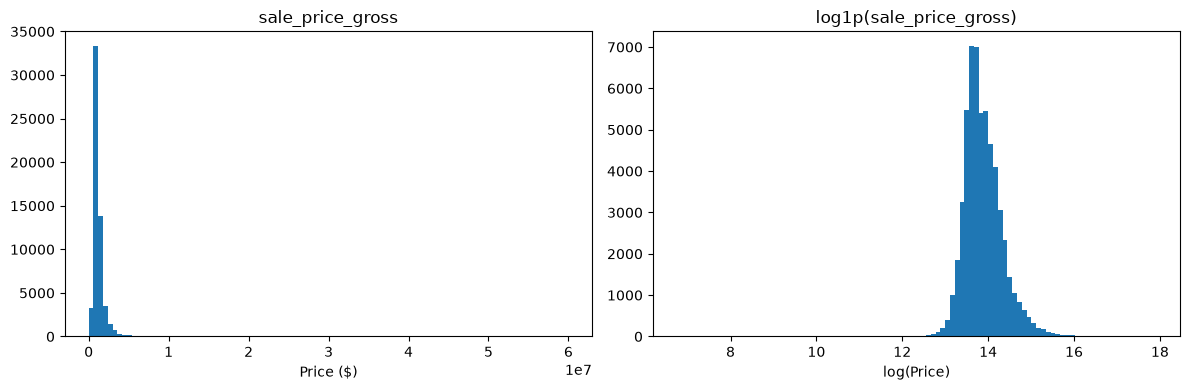

count    5.704400e+04
mean     1.214143e+06
std      8.892736e+05
min      8.500000e+02
25%      8.000000e+05
50%      1.000000e+06
75%      1.371000e+06
max      5.995000e+07
Name: sale_price_gross, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_model["sale_price_gross"], bins=100)
axes[0].set_title("sale_price_gross")
axes[0].set_xlabel("Price ($)")

axes[1].hist(np.log1p(df_model["sale_price_gross"]), bins=100)
axes[1].set_title("log1p(sale_price_gross)")
axes[1].set_xlabel("log(Price)")

plt.tight_layout()
plt.show()

print(df_model["sale_price_gross"].describe())


Right-skewed as expected for prices — `log1p` is a reasonable transform to
consider for the target at model-training time.

### 3.2 Numeric feature correlations with price

sale_price_gross                  1.000000
capital_value                     0.954554
land_value                        0.849843
mass_total_floor_area             0.548768
mass_garage_under_main_roof       0.257869
latitude                          0.119890
off_street_parking                0.111799
land_area                         0.080989
land_value_ratio                  0.063513
dist_to_flood_sensitive_area_m    0.044316
building_total_floor_area         0.015201
longitude                         0.006859
building_site_coverage            0.006561
dist_to_flood_plain_m             0.002536
mass_garage_freestanding         -0.007438
sale_year                        -0.015797
units_of_use                           NaN
Name: sale_price_gross, dtype: float64


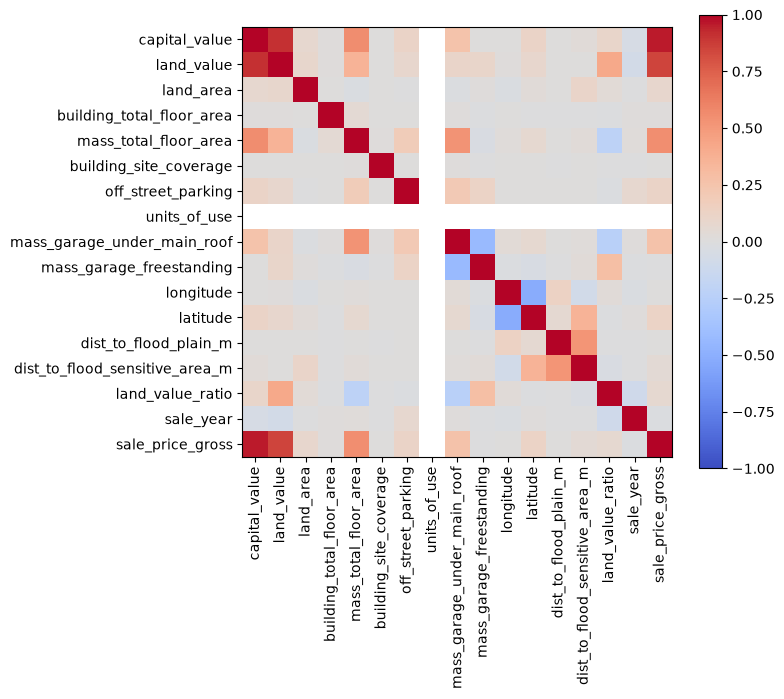

In [11]:
numeric_features = [
    "capital_value", "land_value", "land_area", "building_total_floor_area",
    "mass_total_floor_area", "building_site_coverage", "off_street_parking",
    "units_of_use", "mass_garage_under_main_roof", "mass_garage_freestanding",
    "longitude", "latitude", "dist_to_flood_plain_m", "dist_to_flood_sensitive_area_m",
    "land_value_ratio", "sale_year",
]
corr_matrix = df_model[numeric_features + ["sale_price_gross"]].corr()
print(corr_matrix["sale_price_gross"].sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
labels = numeric_features + ["sale_price_gross"]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
plt.colorbar(im)
plt.tight_layout()
plt.show()


### 3.3 Categorical feature relationships

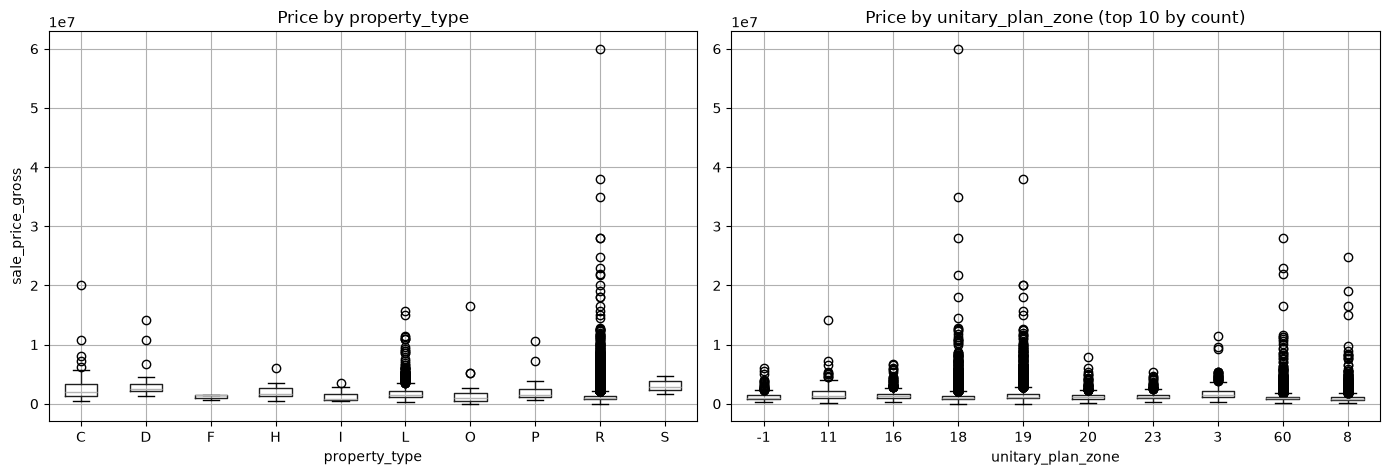

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model.boxplot(column="sale_price_gross", by="property_type", ax=axes[0])
axes[0].set_title("Price by property_type")
axes[0].set_ylabel("sale_price_gross")

top_zones = df_model["unitary_plan_zone"].value_counts().head(10).index
df_model[df_model["unitary_plan_zone"].isin(top_zones)].boxplot(
    column="sale_price_gross", by="unitary_plan_zone", ax=axes[1]
)
axes[1].set_title("Price by unitary_plan_zone (top 10 by count)")

plt.suptitle("")
plt.tight_layout()
plt.show()


### 3.4 Geographic distribution

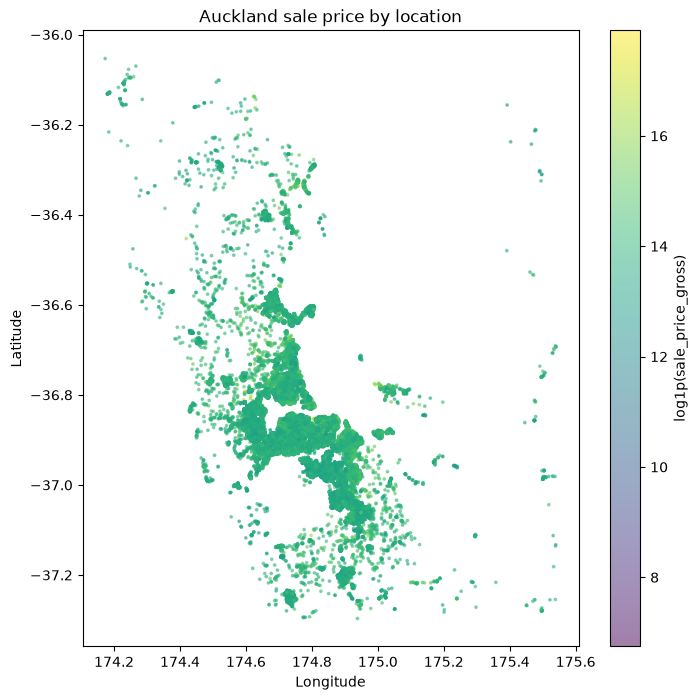

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(
    df_model["longitude"], df_model["latitude"],
    c=np.log1p(df_model["sale_price_gross"]), cmap="viridis", s=3, alpha=0.5,
)
plt.colorbar(sc, label="log1p(sale_price_gross)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Auckland sale price by location")
plt.show()


### 3.5 Price trend over time

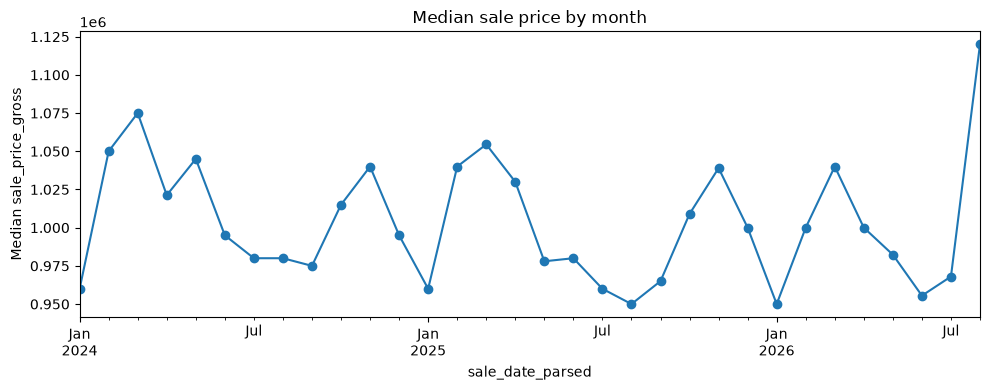

In [14]:
monthly = df_model.groupby(df_model["sale_date_parsed"].dt.to_period("M"))["sale_price_gross"].median()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="o")
ax.set_ylabel("Median sale_price_gross")
ax.set_title("Median sale price by month")
plt.tight_layout()
plt.show()


### 3.6 Flood hazard impact on price

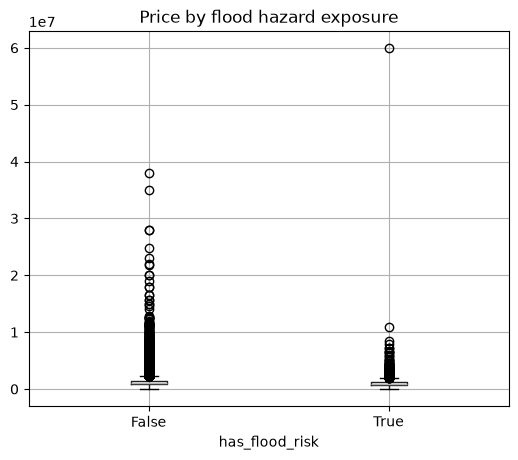

has_flood_risk
False    1015000.0
True      890000.0
Name: sale_price_gross, dtype: float64


In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
df_model.boxplot(column="sale_price_gross", by="has_flood_risk", ax=ax)
ax.set_title("Price by flood hazard exposure")
plt.suptitle("")
plt.show()

print(df_model.groupby("has_flood_risk")["sale_price_gross"].median())


## 4. Prepare for running the model

### 4.1 Final feature/target selection


In [16]:
target_col = "sale_price_gross"

categorical_features = [
    "sale_type", "zoning", "building_age_indicator", "building_condition_indicator",
    "building_construction_indicator", "mass_contour", "mass_view", "mass_scope_of_view",
    "mass_deck", "mass_workshop_laundry", "mass_other_improvements", "unitary_plan_zone",
    "property_type", "matched_suburb", "actual_property_use",
]
numeric_features = [
    "capital_value", "land_value", "land_area", "building_total_floor_area",
    "mass_total_floor_area", "building_site_coverage", "off_street_parking",
    "units_of_use", "mass_garage_under_main_roof", "mass_garage_freestanding",
    "longitude", "latitude", "dist_to_flood_plain_m", "dist_to_flood_sensitive_area_m",
    "land_value_ratio", "sale_year", "sale_month", "sale_quarter",
]
boolean_features = ["in_flood_plain", "in_flood_sensitive_area", "has_flood_risk"]

feature_cols = categorical_features + numeric_features + boolean_features
print(f"{len(feature_cols)} features selected")

for col in categorical_features:
    df_model[col] = df_model[col].astype(str)

X = df_model[feature_cols + ["sale_date_parsed"]].copy()  # keep the date to drive the split, drop it after
y = df_model[target_col].copy()


36 features selected


## Dataset description


**Row counts through the pipeline**:
| Stage | Rows kept |
|---|---|
| Raw sales records | 90,738 |
| → arm's-length market sales only (`price_value_relationship == "1"`) | 73,795 |
| → geocoded street confirmed to exist in LINZ (`street_in_linz`) | 68,266 |
| → time-based split: train (2024-01-01 to 2026-02-10) | 58,057 |
| → time-based split: test (2026-02-11 to 2026-08-18) | 10,209 |
| → after dropping `sale_price_gross` outliers outside 1st-99th percentile of train | 56,991 train / 10,092 test |

**Target**: `sale_price_gross` (native) — gross sale price in NZD, including
chattels. `sale_price_net`/`sale_price_chattels`/`sale_price_other` are
excluded from features since they algebraically sum to the target
(leakage).

**Final feature set: 36 columns**, grouped below. "Source" marks whether a
column comes directly from the council sales file ("Native"), is computed
from native columns ("Derived"), or was added via this project's external
data integration ("External").

**Categorical (15)** — ordinal-encoded before modeling (5.2):

| Feature | Source | Description |
|---|---|---|
| `sale_type` | Native | Sale transaction type (S=standard, M=multi, X, P) |
| `zoning` | Native | District Plan zoning code at valuation date |
| `building_age_indicator` | Native | Coded building-age decade |
| `building_condition_indicator` | Native | Assessed building condition grade |
| `building_construction_indicator` | Native | Wall/construction material code |
| `mass_contour` | Native | Site contour/slope classification |
| `mass_view` | Native | Presence/type of view |
| `mass_scope_of_view` | Native | Extent of the view (none/minor/major) |
| `mass_deck` | Native | Presence of a deck |
| `mass_workshop_laundry` | Native | Presence of a workshop/laundry |
| `mass_other_improvements` | Native | Presence of other site improvements |
| `actual_property_use` | Native | Council code for the property's actual use |
| `property_type` | Derived | First character of `property_category` — broad type (R/C/I/etc.) |
| `matched_suburb` | External — geocoded (`glam`/LINZ) | Suburb resolved from address matching |
| `unitary_plan_zone` | External — Auckland Council Unitary Plan GIS | Base zoning code from spatial join; `-1` = outside any mapped zone |

**Numeric (18)**:

| Feature | Source | Description |
|---|---|---|
| `capital_value` | Native | Council's assessed total value ($) — log1p-transformed (5.2b) |
| `land_value` | Native | Council's assessed land value ($) — log1p-transformed |
| `land_area` | Native | Land area (ha) — log1p-transformed |
| `building_total_floor_area` | Native | Total floor area (m²) — log1p-transformed |
| `mass_total_floor_area` | Native | Mass-appraisal floor area (m²) — log1p-transformed |
| `building_site_coverage` | Native | Building footprint as % of site |
| `off_street_parking` | Native | Off-street parking space count |
| `units_of_use` | Native | Separately usable units on the property |
| `mass_garage_under_main_roof` | Native | Garage spaces under the main roof |
| `mass_garage_freestanding` | Native | Freestanding garage spaces |
| `longitude` / `latitude` | External — geocoded (`glam`/LINZ) | Property coordinates (WGS84) |
| `dist_to_flood_plain_m` | External — Auckland Council Flood Plains GIS | Distance to nearest mapped flood plain (m); `0` = inside |
| `dist_to_flood_sensitive_area_m` | External — Auckland Council Flood Sensitive Areas GIS | Distance to nearest flood-sensitive area (m); `0` = inside |
| `land_value_ratio` | Derived | `land_value / capital_value` |
| `sale_year` / `sale_month` / `sale_quarter` | Derived (from `sale_date`) | Captures market trend over the 2024-2026 window |

**Boolean (3)**:

| Feature | Source | Description |
|---|---|---|
| `in_flood_plain` | External — Auckland Council Flood Plains GIS | Point-in-polygon flood plain flag |
| `in_flood_sensitive_area` | External — Auckland Council Flood Sensitive Areas GIS | Point-in-polygon flood-sensitive flag |
| `has_flood_risk` | Derived | `in_flood_plain OR in_flood_sensitive_area` |


### 4.2 Time-based train/test split

85/15 split by `sale_date` — train on the earlier ~85% of sales, test on
the most recent ~15%, so evaluation reflects predicting *future* prices
from *past* data rather than an optimistic random split.

In [17]:
X_sorted = X.sort_values("sale_date_parsed")
y_sorted = y.loc[X_sorted.index]

split_date = X_sorted["sale_date_parsed"].quantile(0.85, interpolation="nearest")
print(f"Train/test split date: {split_date.date()}")

train_mask = X_sorted["sale_date_parsed"] <= split_date
X_train = X_sorted.loc[train_mask, feature_cols]
X_test = X_sorted.loc[~train_mask, feature_cols]
y_train = y_sorted.loc[train_mask]
y_test = y_sorted.loc[~train_mask]

train_dates = X_sorted.loc[train_mask, "sale_date_parsed"]
test_dates = X_sorted.loc[~train_mask, "sale_date_parsed"]
print(f"Train: {len(X_train):,} rows ({train_dates.min().date()} to {train_dates.max().date()})")
print(f"Test:  {len(X_test):,} rows ({test_dates.min().date()} to {test_dates.max().date()})")


Train/test split date: 2026-02-11
Train: 48,566 rows (2024-01-01 to 2026-02-11)
Test:  8,478 rows (2026-02-12 to 2026-08-18)


### 4.3 Save prepared datasets


In [18]:
MODEL_DATA_DIR = Path("./cache/model_ready")
MODEL_DATA_DIR.mkdir(parents=True, exist_ok=True)

X_train.to_parquet(MODEL_DATA_DIR / "X_train.parquet")
X_test.to_parquet(MODEL_DATA_DIR / "X_test.parquet")
y_train.to_frame(name=target_col).to_parquet(MODEL_DATA_DIR / "y_train.parquet")
y_test.to_frame(name=target_col).to_parquet(MODEL_DATA_DIR / "y_test.parquet")

print(f"Saved train/test sets to {MODEL_DATA_DIR}/")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Categorical features: {categorical_features}")
print(f"Numeric features: {numeric_features}")
print(f"Boolean features: {boolean_features}")


Saved train/test sets to cache\model_ready/
X_train: (48566, 36), X_test: (8478, 36)
Categorical features: ['sale_type', 'zoning', 'building_age_indicator', 'building_condition_indicator', 'building_construction_indicator', 'mass_contour', 'mass_view', 'mass_scope_of_view', 'mass_deck', 'mass_workshop_laundry', 'mass_other_improvements', 'unitary_plan_zone', 'property_type', 'matched_suburb', 'actual_property_use']
Numeric features: ['capital_value', 'land_value', 'land_area', 'building_total_floor_area', 'mass_total_floor_area', 'building_site_coverage', 'off_street_parking', 'units_of_use', 'mass_garage_under_main_roof', 'mass_garage_freestanding', 'longitude', 'latitude', 'dist_to_flood_plain_m', 'dist_to_flood_sensitive_area_m', 'land_value_ratio', 'sale_year', 'sale_month', 'sale_quarter']
Boolean features: ['in_flood_plain', 'in_flood_sensitive_area', 'has_flood_risk']


## 5. Train Random Forest and XGBoost

### 5.1 Handle extreme target outliers

`sale_price_gross` ranges from $1 to $1.79 billion (flagged during EDA) —
almost certainly a mix of nominal/related-party transfers that slipped past
the `price_value_relationship` filter and large commercial/portfolio sales,
not representative market-price residential sales.

In [19]:
p1, p99 = y_train.quantile([0.01, 0.99])

train_keep = y_train.between(p1, p99)
test_keep = y_test.between(p1, p99)

X_train_f = X_train[train_keep].copy()
y_train_f = y_train[train_keep].copy()
X_test_f = X_test[test_keep].copy()
y_test_f = y_test[test_keep].copy()

print(f"Train: {len(X_train_f):,} / {len(X_train):,} kept")
print(f"Test:  {len(X_test_f):,} / {len(X_test):,} kept")


Train: 47,617 / 48,566 kept
Test:  8,324 / 8,478 kept


### 5.2 Encode categorical features

In [20]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
encoder.fit(X_train_f[categorical_features])

X_train_enc = X_train_f.copy()
X_test_enc = X_test_f.copy()
X_train_enc[categorical_features] = encoder.transform(X_train_f[categorical_features])
X_test_enc[categorical_features] = encoder.transform(X_test_f[categorical_features])

# booleans -> 0/1
for col in boolean_features:
    X_train_enc[col] = X_train_enc[col].astype(int)
    X_test_enc[col] = X_test_enc[col].astype(int)

X_train_enc = X_train_enc.astype(float)
X_test_enc = X_test_enc.astype(float)

X_train_enc.head()


,sale_type,zoning,building_age_indicator,building_condition_indicator,building_construction_indicator,mass_contour,mass_view,mass_scope_of_view,mass_deck,mass_workshop_laundry,mass_other_improvements,unitary_plan_zone,property_type,matched_suburb,actual_property_use,capital_value,land_value,land_area,building_total_floor_area,mass_total_floor_area,building_site_coverage,off_street_parking,units_of_use,mass_garage_under_main_roof,mass_garage_freestanding,longitude,latitude,dist_to_flood_plain_m,dist_to_flood_sensitive_area_m,land_value_ratio,sale_year,sale_month,sale_quarter,in_flood_plain,in_flood_sensitive_area,has_flood_risk
45230,0.0,17.0,15.0,12.0,27.0,0.0,0.0,1.0,2.0,0.0,0.0,33.0,8.0,221.0,24.0,930000.0,400000.0,0.0141,140.0,122.0,74.0,1.0,1.0,1.0,0.0,174.597358,-36.867520,0.000000,2248.623626,0.430108,2024.0,1.0,1.0,1.0,0.0,1.0
38158,0.0,0.0,9.0,0.0,14.0,2.0,0.0,1.0,0.0,0.0,0.0,6.0,5.0,65.0,7.0,1175000.0,820000.0,1.6004,120.0,120.0,120.0,0.0,1.0,0.0,2.0,174.769762,-37.216792,0.000000,9101.028065,0.697872,2024.0,1.0,1.0,1.0,0.0,1.0
50675,0.0,15.0,13.0,12.0,91.0,1.0,1.0,2.0,0.0,0.0,0.0,9.0,8.0,83.0,24.0,1265000.0,730000.0,0.0538,190.0,147.0,190.0,2.0,1.0,2.0,0.0,174.611972,-36.890437,201.887500,208.811844,0.577075,2024.0,1.0,1.0,0.0,0.0,0.0
83578,0.0,16.0,14.0,12.0,75.0,3.0,1.0,2.0,2.0,0.0,0.0,8.0,8.0,223.0,24.0,970000.0,880000.0,0.1529,154.0,154.0,105.0,0.0,1.0,0.0,0.0,174.977632,-37.073717,62.773486,333.030188,0.907216,2024.0,1.0,1.0,0.0,0.0,0.0
66417,0.0,17.0,15.0,12.0,75.0,2.0,1.0,2.0,2.0,0.0,0.0,33.0,8.0,68.0,24.0,870000.0,450000.0,0.0116,99.0,99.0,54.0,0.0,1.0,0.0,0.0,174.720467,-36.776988,105.954577,150.587349,0.517241,2024.0,1.0,1.0,0.0,0.0,0.0


### 5.2b Log-transform


In [21]:
skewed_cols = ["capital_value", "land_value", "land_area", "building_total_floor_area", "mass_total_floor_area"]
for col in skewed_cols:
    X_train_enc[col] = np.log1p(X_train_enc[col])
    X_test_enc[col] = np.log1p(X_test_enc[col])

X_train_enc[skewed_cols].describe()


,capital_value,land_value,land_area,building_total_floor_area,mass_total_floor_area
count,47617.000000,47617.000000,47617.000000,47617.000000,47617.000000
mean,13.936398,13.451582,0.073602,4.800410,4.681683
std,0.409172,0.533137,0.238275,0.889507,0.880394
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.641158,13.060490,0.007174,4.584967,4.521789
50%,13.887832,13.415034,0.034595,4.897840,4.770685
75%,14.180154,13.785052,0.064757,5.231109,5.068904
max,16.380460,16.334013,5.525115,9.211640,6.548219


### 5.2c Multicollinearity pruning

In [22]:
corr_matrix = X_train_enc[numeric_features].corr()
print(corr_matrix.round(2))

# For each pair of features correlated with each other (|r| > 0.7), drop
# whichever correlates less strongly with the target (sale_price_gross),
# keeping the more predictive one.
to_drop = set()
pair_decisions = []
for i, a in enumerate(numeric_features):
    for b in numeric_features[i + 1:]:
        r = corr_matrix.loc[a, b]
        if abs(r) > 0.7:
            corr_a_target = abs(X_train_enc[a].corr(y_train_f))
            corr_b_target = abs(X_train_enc[b].corr(y_train_f))
            drop_col, keep_col = (a, b) if corr_a_target < corr_b_target else (b, a)
            to_drop.add(drop_col)
            pair_decisions.append((a, b, r, drop_col, keep_col, corr_a_target, corr_b_target))

print(f"\n{len(pair_decisions)} feature pair(s) exceeded |r| > 0.7:")
for a, b, r, drop_col, keep_col, corr_a_target, corr_b_target in pair_decisions:
    print(
        f"  {a} vs {b}: r={r:.3f}  "
        f"(corr with target: {a}={corr_a_target:.3f}, {b}={corr_b_target:.3f})  "
        f"-> dropping '{drop_col}', keeping '{keep_col}'"
    )

print(f"\nDropping {len(to_drop)} redundant feature(s): {sorted(to_drop)}")

numeric_features_pruned = [c for c in numeric_features if c not in to_drop]
X_train_enc = X_train_enc.drop(columns=list(to_drop))
X_test_enc = X_test_enc.drop(columns=list(to_drop))

print(f"Remaining features: {X_train_enc.shape[1]} (numeric: {len(numeric_features_pruned)})")


                                capital_value  land_value  land_area  \
capital_value                            1.00        0.84       0.18   
land_value                               0.84        1.00       0.18   
land_area                                0.18        0.18       1.00   
building_total_floor_area                0.40        0.17      -0.08   
mass_total_floor_area                    0.36        0.15      -0.12   
building_site_coverage                   0.00        0.00       0.00   
off_street_parking                       0.13        0.10       0.03   
units_of_use                              NaN         NaN        NaN   
mass_garage_under_main_roof              0.36        0.16       0.01   
mass_garage_freestanding                -0.01        0.15       0.10   
longitude                               -0.01        0.01      -0.08   
latitude                                 0.17        0.13       0.08   
dist_to_flood_plain_m                    0.00        0.00       

### 5.3 Random Forest



In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train_enc, y_train_f)
print("Random Forest trained")


Random Forest trained


### 5.4 XGBoost

In [24]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train_enc, y_train_f)
print("XGBoost trained")


XGBoost trained


### 5.5 Evaluate on the test set

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate(name, model, X, y_true):
    y_pred = model.predict(X)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:15s}  RMSE=${rmse:,.0f}   MAE=${mae:,.0f}   R2={r2:.4f}")
    return y_pred


rf_pred = evaluate("Random Forest", rf_model, X_test_enc, y_test_f)
xgb_pred = evaluate("XGBoost", xgb_model, X_test_enc, y_test_f)


Random Forest    RMSE=$133,564   MAE=$87,234   R2=0.9386
XGBoost          RMSE=$131,899   MAE=$86,696   R2=0.9401


Results recorded before feature selection and prunning.

No multicollinearity prunning: 
 - Random Forest    RMSE=$399,881   MAE=$140,900   R2=0.8092
 - XGBoost          RMSE=$370,512   MAE=$138,262   R2=0.8362

multicollinearity prunning:
 - Random Forest    RMSE=$379,870   MAE=$140,548   R2=0.8279
 - XGBoost          RMSE=$376,590   MAE=$141,470   R2=0.8308
    

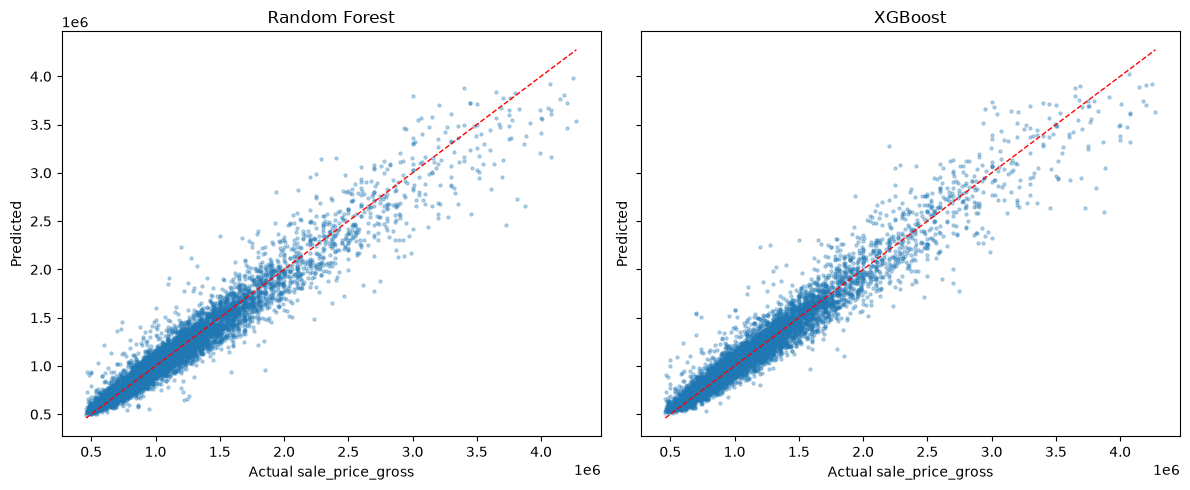

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, name, pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred, xgb_pred]):
    ax.scatter(y_test_f, pred, s=5, alpha=0.3)
    lims = [y_test_f.min(), y_test_f.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual sale_price_gross")
    ax.set_ylabel("Predicted")
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 6. Explain feature importance with SHAP



In [27]:
import shap

shap_sample = X_test_enc.sample(n=min(300, len(X_test_enc)), random_state=42)
print(f"Computing SHAP values on a sample of {len(shap_sample):,} test rows")


Computing SHAP values on a sample of 300 test rows


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 6.1 Random Forest feature importance

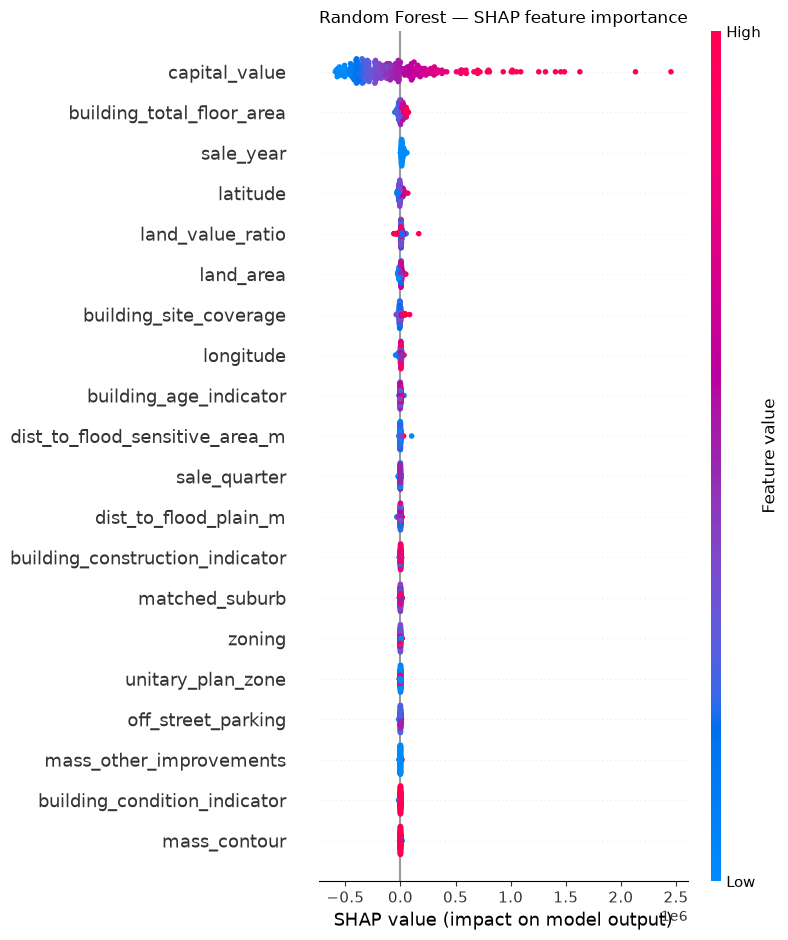

In [28]:
rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(shap_sample)

shap.summary_plot(rf_shap_values, shap_sample, show=False)
plt.title("Random Forest — SHAP feature importance")
plt.tight_layout()
plt.show()


### 6.2 XGBoost feature importance

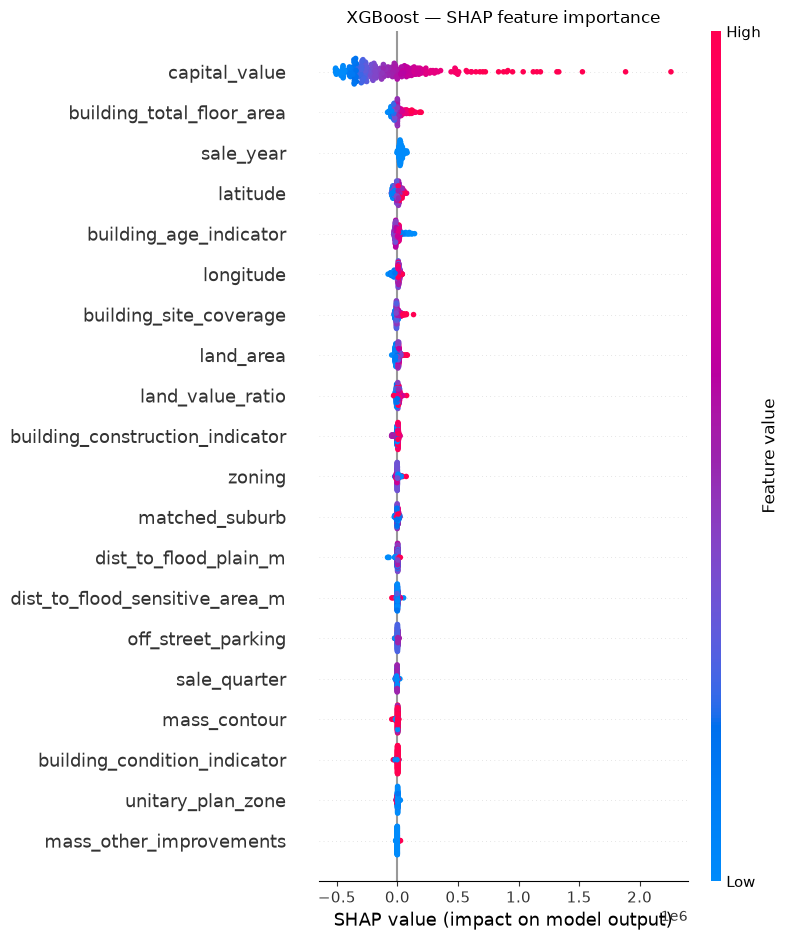

In [29]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(shap_sample)

shap.summary_plot(xgb_shap_values, shap_sample, show=False)
plt.title("XGBoost — SHAP feature importance")
plt.tight_layout()
plt.show()


### 6.3 Compare mean SHAP ranking between the two models

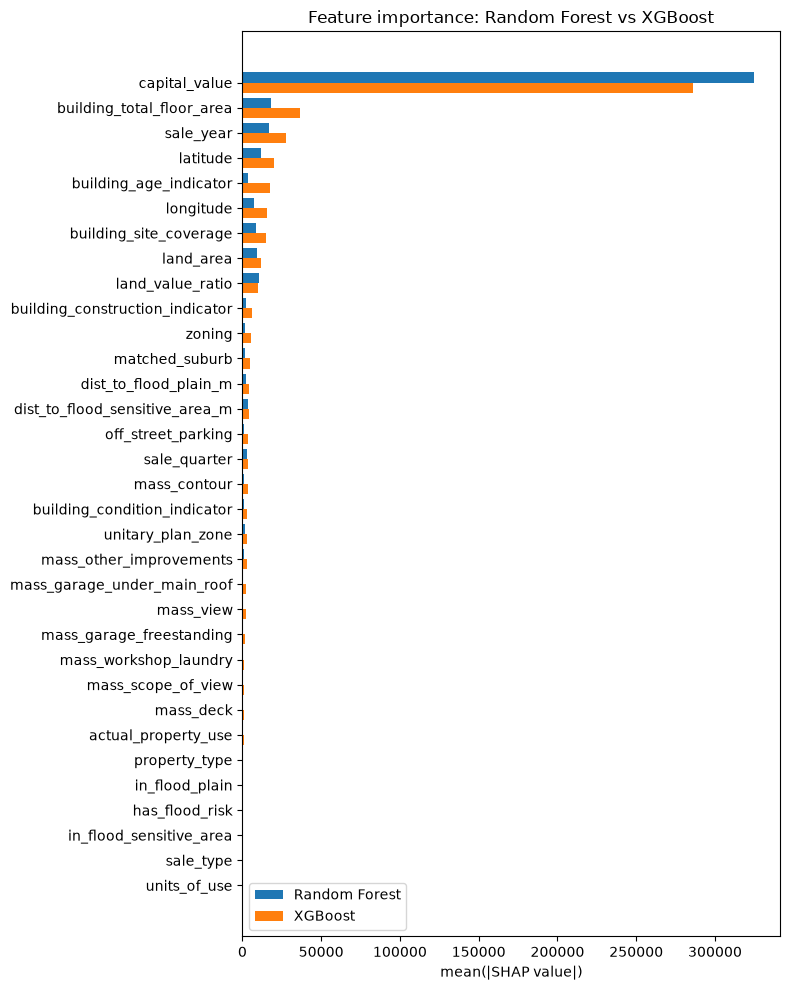

,feature,rf_mean_abs_shap,xgb_mean_abs_shap
15,capital_value,325024.967987,285984.656250
17,building_total_floor_area,18094.253465,36697.085938
28,sale_year,16619.165304,27478.261719
24,latitude,11866.472496,19983.052734
2,building_age_indicator,3436.474540,17592.396484
23,longitude,7040.530109,15380.825195
18,building_site_coverage,8441.473865,14931.542969
16,land_area,9301.566798,11621.398438
27,land_value_ratio,10704.767217,9695.069336
4,building_construction_indicator,2026.805583,6362.336426


In [30]:
importance_comparison = pd.DataFrame({
    "feature": shap_sample.columns,
    "rf_mean_abs_shap": np.abs(rf_shap_values).mean(axis=0),
    "xgb_mean_abs_shap": np.abs(xgb_shap_values).mean(axis=0),
}).sort_values("xgb_mean_abs_shap", ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
y_pos = np.arange(len(importance_comparison))
ax.barh(y_pos - 0.2, importance_comparison["rf_mean_abs_shap"], height=0.4, label="Random Forest")
ax.barh(y_pos + 0.2, importance_comparison["xgb_mean_abs_shap"], height=0.4, label="XGBoost")
ax.set_yticks(y_pos)
ax.set_yticklabels(importance_comparison["feature"])
ax.invert_yaxis()
ax.set_xlabel("mean(|SHAP value|)")
ax.set_title("Feature importance: Random Forest vs XGBoost")
ax.legend()
plt.tight_layout()
plt.show()

importance_comparison


## 9. Keep `capital_value`, but down-weight it

Instead of dropping `capital_value` (section 5.2d), add it back and reduce
how much the model can lean on it. Tree models are scale-invariant, so
"weight" here means XGBoost's `feature_weights`: the sampling probability
of each feature when a split's candidate columns are drawn
(`colsample_bynode=0.5`). A low weight makes `capital_value` available at
fewer splits, so other features get to explain more of the variance.
It is a soft limit, not a hard cap. The sweep compares weights from 1.0
(no down-weighting) to 0.02, reporting test accuracy and
`capital_value`'s share of total mean |SHAP|.


In [31]:
import xgboost as xgb

# capital_value back in (log1p, same as 5.2b), appended as the last column
X_train_w = X_train_enc.copy()
X_test_w = X_test_enc.copy()
X_train_w["capital_value"] = np.log1p(X_train_f["capital_value"].astype(float))
X_test_w["capital_value"] = np.log1p(X_test_f["capital_value"].astype(float))
cv_idx = list(X_train_w.columns).index("capital_value")

shap_rows = X_test_w.sample(n=min(2000, len(X_test_w)), random_state=42)

results_w = []
models_w = {}
for cv_weight in [1.0, 0.3, 0.1, 0.02]:
    fw = np.ones(X_train_w.shape[1])
    fw[cv_idx] = cv_weight
    m = XGBRegressor(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bynode=0.5,
        random_state=42,
        n_jobs=-1,
    )
    m.fit(X_train_w, y_train_f, feature_weights=fw)
    pred = m.predict(X_test_w)
    contrib = m.get_booster().predict(xgb.DMatrix(shap_rows), pred_contribs=True)[:, :-1]
    mean_abs = np.abs(contrib).mean(axis=0)
    results_w.append({
        "cv_weight": cv_weight,
        "RMSE": mean_squared_error(y_test_f, pred) ** 0.5,
        "MAE": mean_absolute_error(y_test_f, pred),
        "R2": r2_score(y_test_f, pred),
        "cv_shap_share": mean_abs[cv_idx] / mean_abs.sum(),
    })
    models_w[cv_weight] = m

results_w = pd.DataFrame(results_w).set_index("cv_weight")
print(results_w.round(4))
print()
print("Reference (capital_value dropped, section 5): XGBoost R2=0.8199, RMSE=$267,967")
print("Reference (capital_value kept, no weighting, plain XGBoost): R2=0.9386, RMSE=$156,501")


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\xgboost\sklearn.py:1252: UserWarning: `feature_weights` in `fit` method is deprecated for better compatibility with scikit-learn, use `feature_weights` in constructor or`set_params` instead.
  warnings.warn(


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\xgboost\sklearn.py:1252: UserWarning: `feature_weights` in `fit` method is deprecated for better compatibility with scikit-learn, use `feature_weights` in constructor or`set_params` instead.
  warnings.warn(


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\xgboost\sklearn.py:1252: UserWarning: `feature_weights` in `fit` method is deprecated for better compatibility with scikit-learn, use `feature_weights` in constructor or`set_params` instead.
  warnings.warn(


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\xgboost\sklearn.py:1252: UserWarning: `feature_weights` in `fit` method is deprecated for better compatibility with scikit-learn, use `feature_weights` in constructor or`set_params` instead.
  warnings.warn(


                  RMSE          MAE      R2  cv_shap_share
cv_weight                                                 
1.00       131939.4421   86947.9375  0.9401         0.5100
0.30       133077.5240   88882.8359  0.9390         0.4005
0.10       146590.7461   97538.7031  0.9260         0.2796
0.02       196297.5674  129162.3516  0.8673         0.0908

Reference (capital_value dropped, section 5): XGBoost R2=0.8199, RMSE=$267,967
Reference (capital_value kept, no weighting, plain XGBoost): R2=0.9386, RMSE=$156,501


### 9.1 Feature ranking under the lowest weight


In [32]:
best_w = min(models_w)
contrib = models_w[best_w].get_booster().predict(xgb.DMatrix(shap_rows), pred_contribs=True)[:, :-1]
rank_w = pd.Series(np.abs(contrib).mean(axis=0), index=X_train_w.columns).sort_values(ascending=False)
print(f"Mean |SHAP| with capital_value weight = {best_w}")
print(rank_w.head(10).round(0))


Mean |SHAP| with capital_value weight = 0.02
building_total_floor_area          155399.0
latitude                            88230.0
capital_value                       66992.0
longitude                           62370.0
land_area                           60333.0
building_site_coverage              56932.0
building_age_indicator              54411.0
land_value_ratio                    36353.0
building_construction_indicator     19746.0
mass_view                           15685.0
dtype: float32


### 9.2 SHAP summary plot for each `capital_value` weight

One beeswarm per model from the sweep above (500 test rows, top 15
features), to see how `capital_value`'s spread and rank change as its
weight drops.


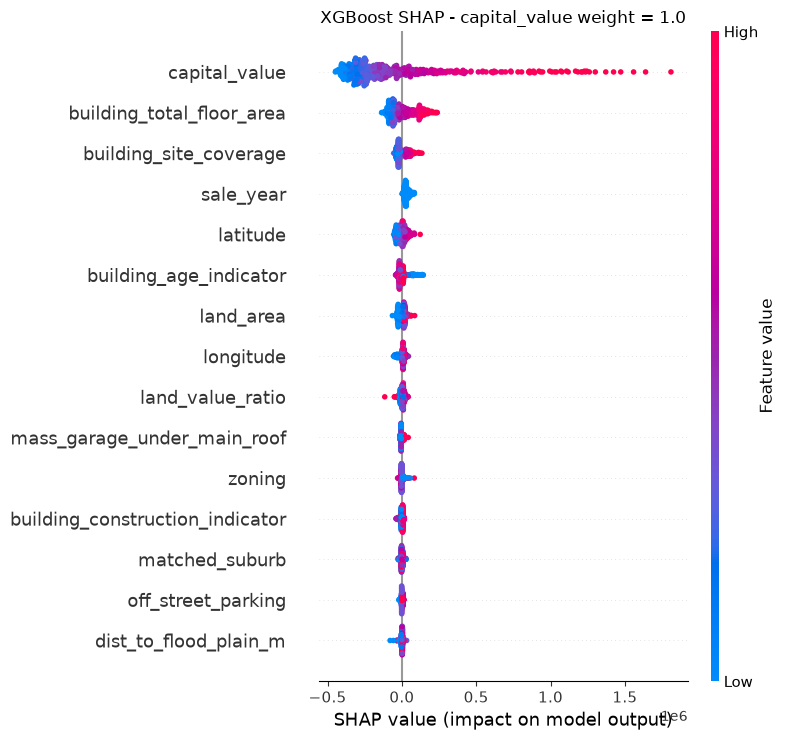

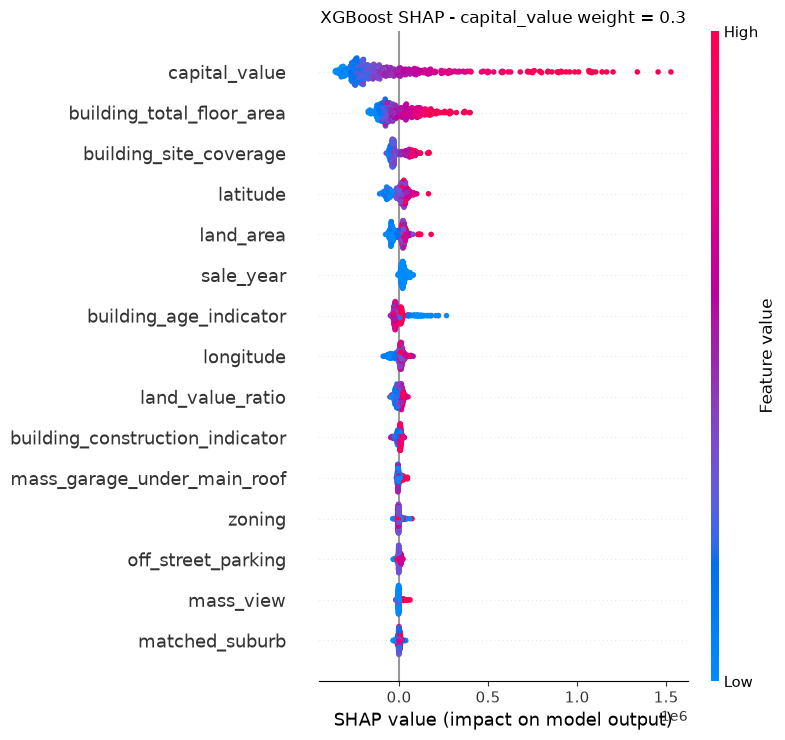

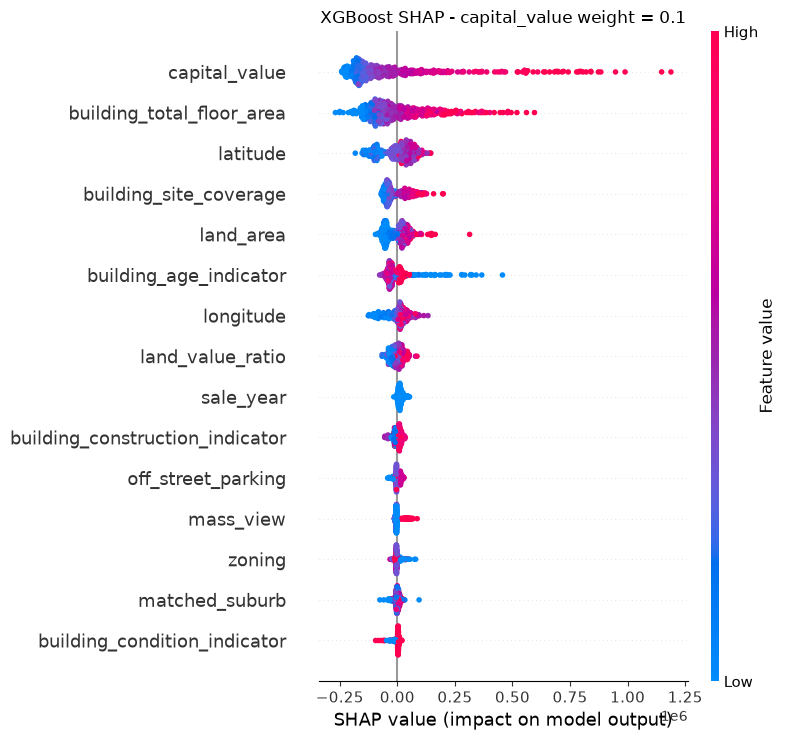

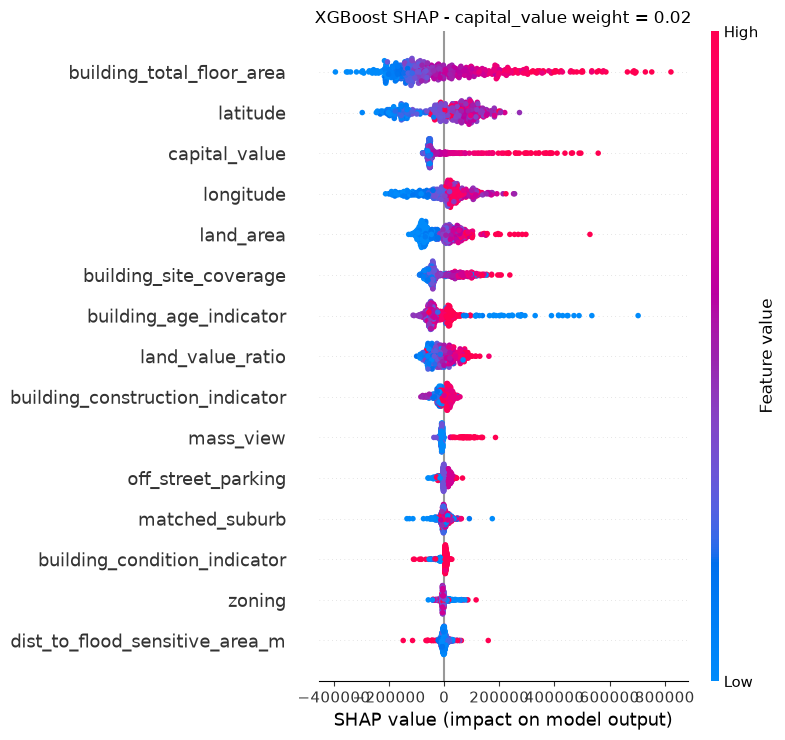

In [33]:
shap_plot_rows = shap_rows.sample(n=500, random_state=42)
for cv_weight, m in models_w.items():
    sv = shap.TreeExplainer(m).shap_values(shap_plot_rows)
    shap.summary_plot(sv, shap_plot_rows, max_display=15, show=False)
    plt.title(f"XGBoost SHAP - capital_value weight = {cv_weight}")
    plt.tight_layout()
    plt.show()


### 9.3 Random Forest with `capital_value` weight = 0.3

scikit-learn's `RandomForestRegressor` has no per-feature sampling weights,
so this uses XGBoost's random-forest mode (`XGBRFRegressor`), which
supports `feature_weights`. Settings mirror section 5.3 as closely as
possible (150 trees, depth 18), with `colsample_bynode=0.5` so the weight
takes effect. Evaluated on the test set, then plotted with SHAP.


D:\Codes\COMPSCI_760_Group_3_Intelligent_Real_Estate_Price_Prediction_Model\.venv\Lib\site-packages\xgboost\core.py:569: FutureWarning: `XGBRFRegressor` is deprecated and will be removed in a future release. The estimator is a thin wrapper over the boosting interface and does not implement a conventional random forest; features like early stopping are unsupported. Set `num_parallel_tree` along with `n_estimators=1` on the corresponding boosting estimator instead, or use a dedicated random forest implementation like those in `sklearn.ensemble`.
  return func(**kwargs)


RF (cv weight 0.3)  RMSE=$142,293   MAE=$91,487   R2=0.9303


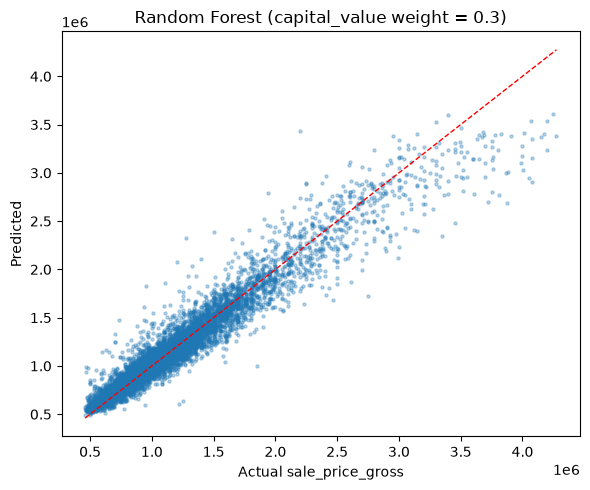

In [34]:
from xgboost import XGBRFRegressor

fw_rf = np.ones(X_train_w.shape[1])
fw_rf[cv_idx] = 0.3

rf_model_w = XGBRFRegressor(
    n_estimators=150,
    max_depth=18,
    subsample=0.8,
    colsample_bynode=0.5,
    feature_weights=fw_rf,
    random_state=42,
    n_jobs=-1,
)
rf_model_w.fit(X_train_w, y_train_f)

rf_pred_w = evaluate("RF (cv weight 0.3)", rf_model_w, X_test_w, y_test_f)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_f, rf_pred_w, s=5, alpha=0.3)
lims = [y_test_f.min(), y_test_f.max()]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual sale_price_gross")
ax.set_ylabel("Predicted")
ax.set_title("Random Forest (capital_value weight = 0.3)")
plt.tight_layout()
plt.show()


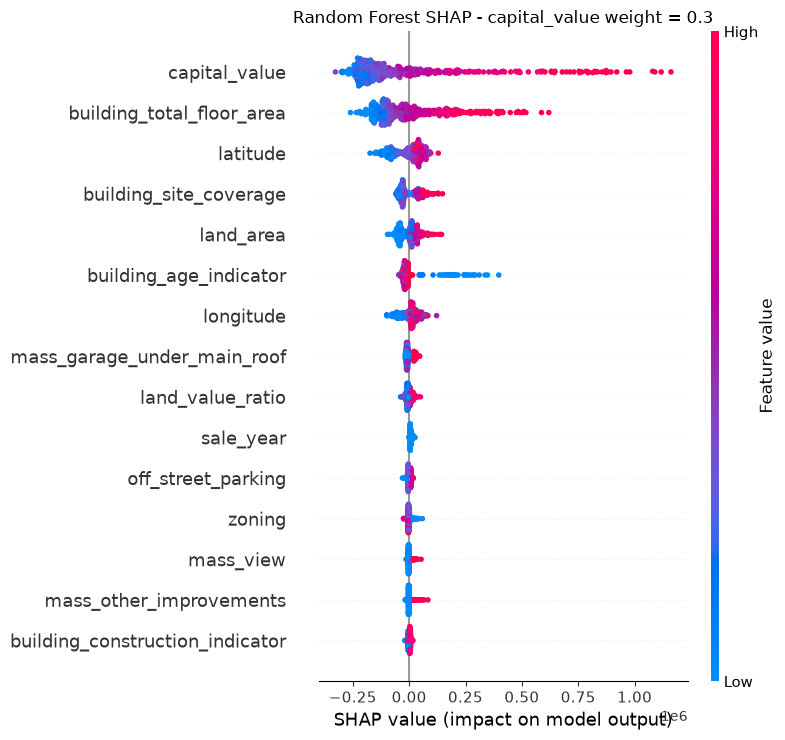

capital_value share of total mean |SHAP|: 0.353


In [35]:
rf_sv_w = shap.TreeExplainer(rf_model_w).shap_values(shap_plot_rows)
shap.summary_plot(rf_sv_w, shap_plot_rows, max_display=15, show=False)
plt.title("Random Forest SHAP - capital_value weight = 0.3")
plt.tight_layout()
plt.show()

rf_share = np.abs(rf_sv_w).mean(axis=0)
print(f"capital_value share of total mean |SHAP|: {rf_share[cv_idx] / rf_share.sum():.3f}")


## 10. Original data only (no external data)

Ablation: retrain both models using only columns that come from (or are
derived purely from) the Auckland Council DVR data, with every externally
sourced feature removed -- geocoded coordinates (`longitude`, `latitude`,
`matched_suburb`), the flood-hazard columns, and the GIS-derived
`unitary_plan_zone`. Same rows, same split, same hyperparameters and same
pruning as sections 5, so the only difference is the feature set.


In [36]:
external_cols = [
    "matched_suburb", "unitary_plan_zone", "longitude", "latitude",
    "dist_to_flood_plain_m", "dist_to_flood_sensitive_area_m",
    "in_flood_plain", "in_flood_sensitive_area", "has_flood_risk",
]
orig_cols = [c for c in X_train_enc.columns if c not in external_cols]
print(f"{len(orig_cols)} original-data features (removed {len(X_train_enc.columns) - len(orig_cols)} external)")
print(orig_cols)

X_train_orig = X_train_enc[orig_cols]
X_test_orig = X_test_enc[orig_cols]

rf_model_orig = RandomForestRegressor(
    n_estimators=150, max_depth=18, min_samples_leaf=2, n_jobs=-1, random_state=42,
)
rf_model_orig.fit(X_train_orig, y_train_f)

xgb_model_orig = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1,
)
xgb_model_orig.fit(X_train_orig, y_train_f)

print("\nOriginal data only:")
rf_pred_orig = evaluate("Random Forest", rf_model_orig, X_test_orig, y_test_f)
xgb_pred_orig = evaluate("XGBoost", xgb_model_orig, X_test_orig, y_test_f)
print("\nWith external data (sections 5):")
evaluate("Random Forest", rf_model, X_test_enc, y_test_f)
evaluate("XGBoost", xgb_model, X_test_enc, y_test_f);


24 original-data features (removed 9 external)
['sale_type', 'zoning', 'building_age_indicator', 'building_condition_indicator', 'building_construction_indicator', 'mass_contour', 'mass_view', 'mass_scope_of_view', 'mass_deck', 'mass_workshop_laundry', 'mass_other_improvements', 'property_type', 'actual_property_use', 'capital_value', 'land_area', 'building_total_floor_area', 'building_site_coverage', 'off_street_parking', 'units_of_use', 'mass_garage_under_main_roof', 'mass_garage_freestanding', 'land_value_ratio', 'sale_year', 'sale_quarter']



Original data only:
Random Forest    RMSE=$135,161   MAE=$89,513   R2=0.9371
XGBoost          RMSE=$133,604   MAE=$88,246   R2=0.9385

With external data (sections 5):
Random Forest    RMSE=$133,564   MAE=$87,234   R2=0.9386
XGBoost          RMSE=$131,899   MAE=$86,696   R2=0.9401


### 10.1 Predicted vs actual (original data only)


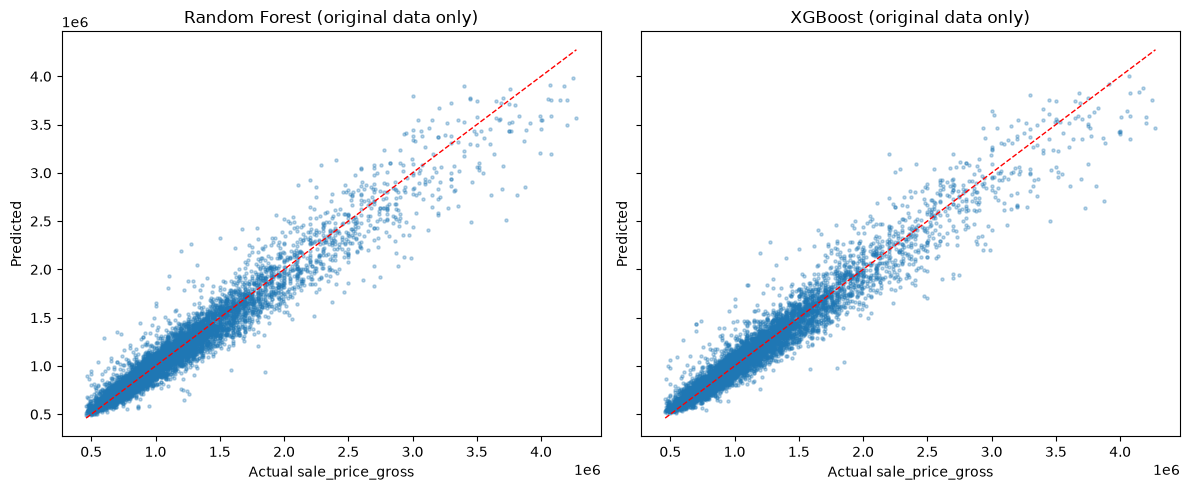

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, name, pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred_orig, xgb_pred_orig]):
    ax.scatter(y_test_f, pred, s=5, alpha=0.3)
    lims = [y_test_f.min(), y_test_f.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual sale_price_gross")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} (original data only)")
plt.tight_layout()
plt.show()


### 10.2 SHAP feature importance (original data only)


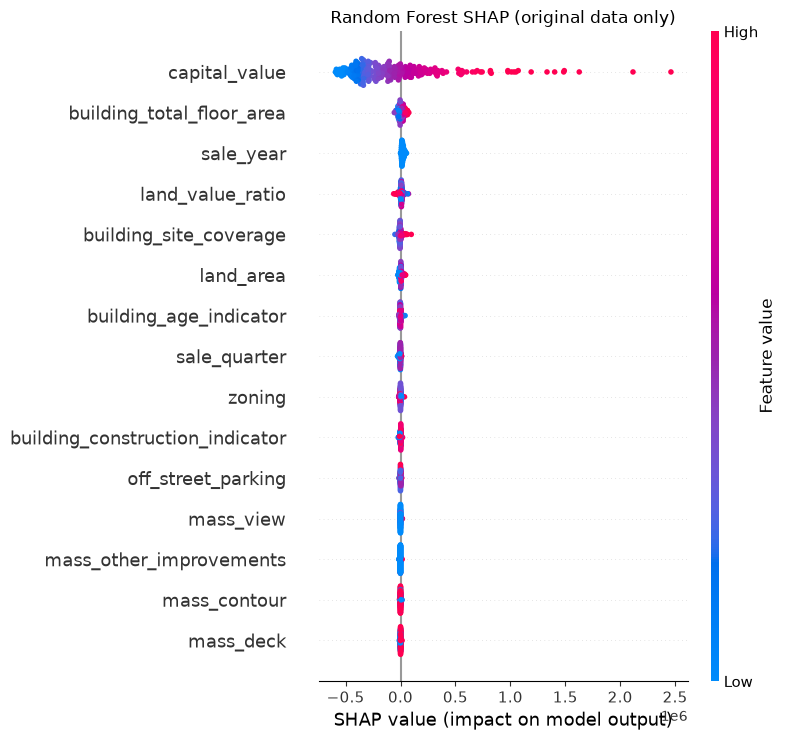

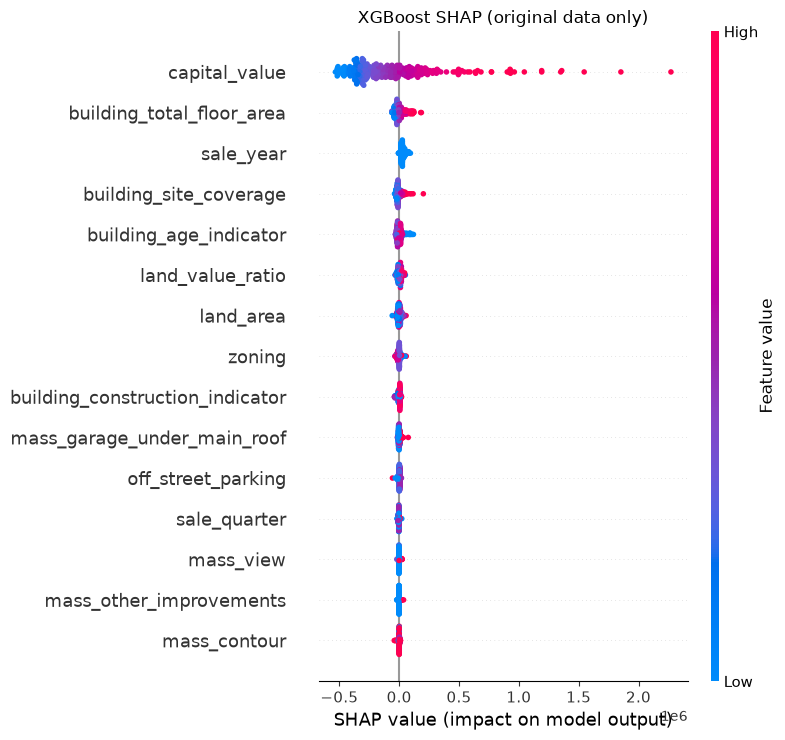

,feature,rf_mean_abs_shap,xgb_mean_abs_shap
13,capital_value,327478.532366,293480.031250
15,building_total_floor_area,18822.899003,31088.187500
22,sale_year,18802.572673,29549.353516
16,building_site_coverage,9160.894186,18203.789062
2,building_age_indicator,4443.284718,16939.572266
21,land_value_ratio,11431.214466,11079.786133
14,land_area,8269.655167,9474.904297
1,zoning,3791.664852,9452.552734
4,building_construction_indicator,3557.403128,7207.650879
19,mass_garage_under_main_roof,942.950212,5784.621094


In [38]:
shap_sample_orig = X_test_orig.sample(n=min(300, len(X_test_orig)), random_state=42)

rf_sv_orig = shap.TreeExplainer(rf_model_orig).shap_values(shap_sample_orig)
shap.summary_plot(rf_sv_orig, shap_sample_orig, max_display=15, show=False)
plt.title("Random Forest SHAP (original data only)")
plt.tight_layout()
plt.show()

xgb_sv_orig = shap.TreeExplainer(xgb_model_orig).shap_values(shap_sample_orig)
shap.summary_plot(xgb_sv_orig, shap_sample_orig, max_display=15, show=False)
plt.title("XGBoost SHAP (original data only)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": orig_cols,
    "rf_mean_abs_shap": np.abs(rf_sv_orig).mean(axis=0),
    "xgb_mean_abs_shap": np.abs(xgb_sv_orig).mean(axis=0),
}).sort_values("xgb_mean_abs_shap", ascending=False).head(15)


## 11. Drop `capital_value` completely

Retrain both models on the full feature set (external data included) with
`capital_value` removed. Note `land_value` was already dropped by the
multicollinearity pruning in 5.2c (it correlates with `capital_value`), so
no council valuation figure is left; only `land_value_ratio` remains.


32 features (capital_value removed)



Without capital_value:
Random Forest    RMSE=$252,971   MAE=$154,673   R2=0.7797
XGBoost          RMSE=$237,399   MAE=$147,971   R2=0.8060

With capital_value (section 5):
Random Forest    RMSE=$133,564   MAE=$87,234   R2=0.9386
XGBoost          RMSE=$131,899   MAE=$86,696   R2=0.9401


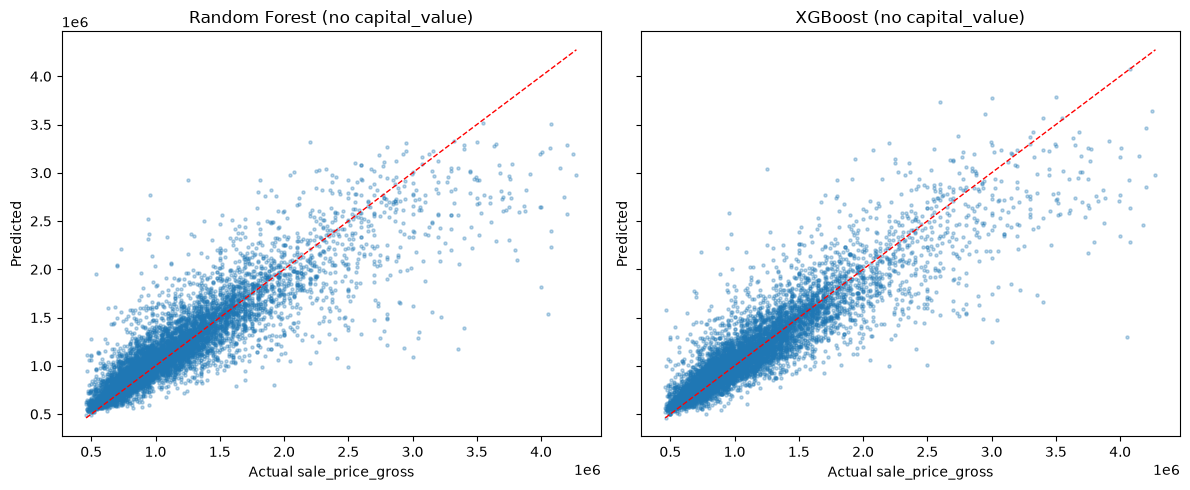

In [39]:
X_train_nocv = X_train_enc.drop(columns=["capital_value"])
X_test_nocv = X_test_enc.drop(columns=["capital_value"])
print(f"{X_train_nocv.shape[1]} features (capital_value removed)")

rf_model_nocv = RandomForestRegressor(
    n_estimators=150, max_depth=18, min_samples_leaf=2, n_jobs=-1, random_state=42,
)
rf_model_nocv.fit(X_train_nocv, y_train_f)

xgb_model_nocv = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42, n_jobs=-1,
)
xgb_model_nocv.fit(X_train_nocv, y_train_f)

print("\nWithout capital_value:")
rf_pred_nocv = evaluate("Random Forest", rf_model_nocv, X_test_nocv, y_test_f)
xgb_pred_nocv = evaluate("XGBoost", xgb_model_nocv, X_test_nocv, y_test_f)
print("\nWith capital_value (section 5):")
evaluate("Random Forest", rf_model, X_test_enc, y_test_f)
evaluate("XGBoost", xgb_model, X_test_enc, y_test_f);

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, name, pred in zip(axes, ["Random Forest", "XGBoost"], [rf_pred_nocv, xgb_pred_nocv]):
    ax.scatter(y_test_f, pred, s=5, alpha=0.3)
    lims = [y_test_f.min(), y_test_f.max()]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual sale_price_gross")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name} (no capital_value)")
plt.tight_layout()
plt.show()


### 11.1 SHAP feature importance (no `capital_value`)


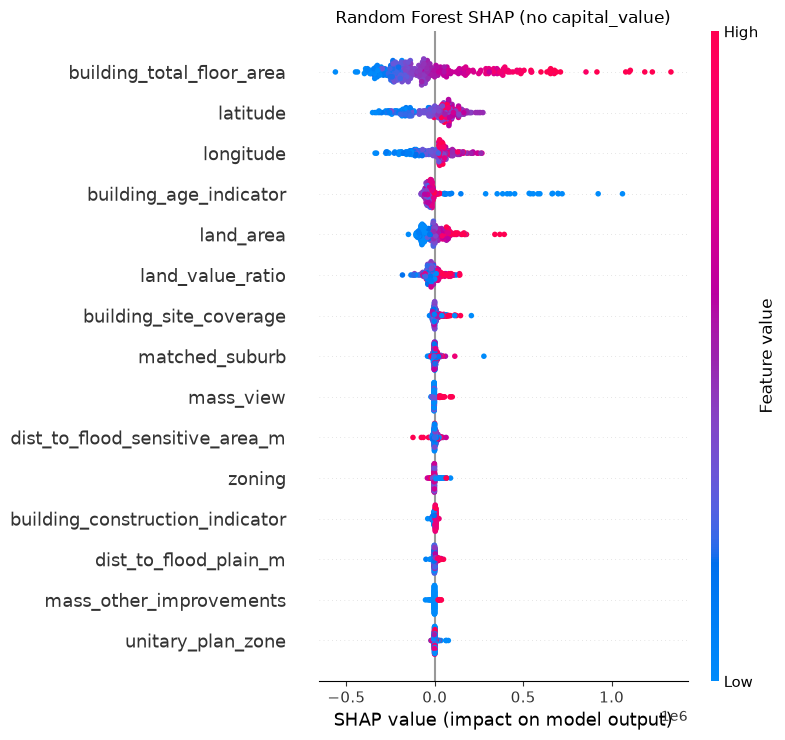

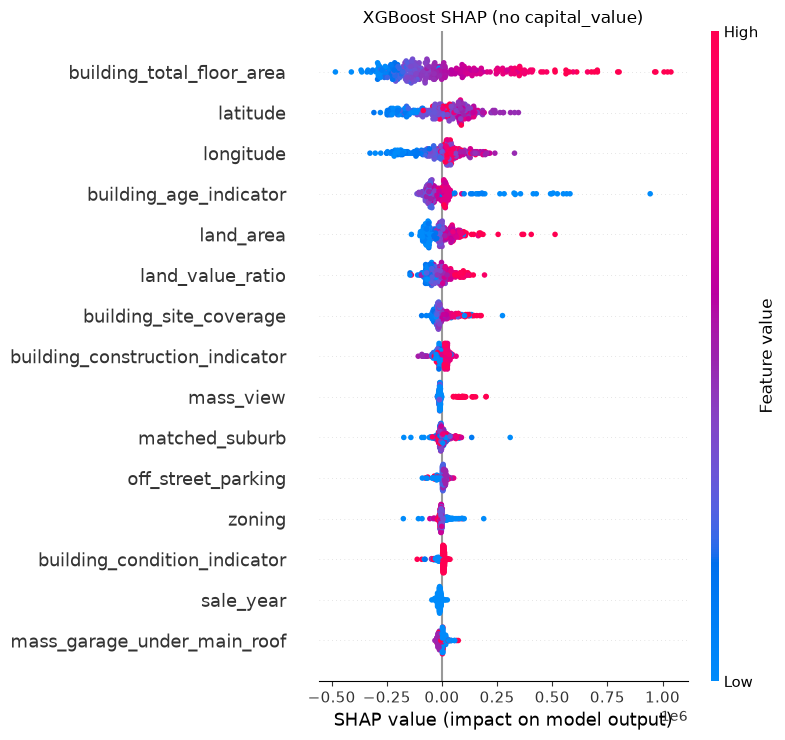

,feature,rf_mean_abs_shap,xgb_mean_abs_shap
16,building_total_floor_area,236797.411691,202180.109375
23,latitude,103103.858761,103729.976562
22,longitude,80631.875311,79080.195312
2,building_age_indicator,66883.220910,63994.464844
15,land_area,53195.067970,54401.554688
26,land_value_ratio,34135.229431,45613.726562
17,building_site_coverage,15250.654445,33676.570312
4,building_construction_indicator,5963.033073,20827.601562
6,mass_view,8292.194543,20315.351562
13,matched_suburb,8426.537754,18658.517578


In [40]:
shap_sample_nocv = X_test_nocv.sample(n=min(300, len(X_test_nocv)), random_state=42)

rf_sv_nocv = shap.TreeExplainer(rf_model_nocv).shap_values(shap_sample_nocv)
shap.summary_plot(rf_sv_nocv, shap_sample_nocv, max_display=15, show=False)
plt.title("Random Forest SHAP (no capital_value)")
plt.tight_layout()
plt.show()

xgb_sv_nocv = shap.TreeExplainer(xgb_model_nocv).shap_values(shap_sample_nocv)
shap.summary_plot(xgb_sv_nocv, shap_sample_nocv, max_display=15, show=False)
plt.title("XGBoost SHAP (no capital_value)")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": X_train_nocv.columns,
    "rf_mean_abs_shap": np.abs(rf_sv_nocv).mean(axis=0),
    "xgb_mean_abs_shap": np.abs(xgb_sv_nocv).mean(axis=0),
}).sort_values("xgb_mean_abs_shap", ascending=False).head(15)
